# Algoritmo Eclat - Reglas de Asociación

**Objetivo**: Identificar conjuntos de ítems que aparecen frecuentemente juntos en transacciones utilizando el algoritmo Eclat.

**Características principales**:
- Formato vertical de datos (TID-lists)
- Búsqueda en profundidad (depth-first search)
- Intersección de listas de transacciones para calcular soporte

**Dataset**: Market Basket Optimization (transacciones de un supermercado)

**Bibliotecas**: pandas, mlxtend

In [1]:
# Instalar mlxtend para el algoritmo Eclat
!pip install mlxtend -q

print("✅ Librerías instaladas correctamente")

✅ Librerías instaladas correctamente


In [2]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [3]:
# Datos de ejemplo: transacciones de un supermercado
transactions = [
    ['leche', 'pan', 'huevos'],
    ['cerveza', 'pan', 'leche'],
    ['leche', 'huevos', 'mantequilla'],
    ['cerveza', 'huevos'],
    ['leche', 'pan', 'huevos', 'mantequilla'],
    ['cerveza', 'pan', 'mantequilla'],
    ['leche', 'pan'],
    ['cerveza', 'leche', 'huevos', 'pan'],
    ['leche', 'huevos', 'pan'],
    ['cerveza', 'mantequilla']
]

print(f"📊 Número de transacciones: {len(transactions)}")
print("\n📋 Primeras 5 transacciones:")
for i in range(5):
    print(f"  Transacción {i+1}: {transactions[i]}")

📊 Número de transacciones: 10

📋 Primeras 5 transacciones:
  Transacción 1: ['leche', 'pan', 'huevos']
  Transacción 2: ['cerveza', 'pan', 'leche']
  Transacción 3: ['leche', 'huevos', 'mantequilla']
  Transacción 4: ['cerveza', 'huevos']
  Transacción 5: ['leche', 'pan', 'huevos', 'mantequilla']


In [4]:
# Codificar las transacciones en formato one-hot (necesario para mlxtend)
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print("📋 Datos codificados (primeras 5 filas):")
print(df_encoded.head())
print(f"\n📊 Dimensiones: {df_encoded.shape}")
print(f"📌 Items: {df_encoded.columns.tolist()}")

📋 Datos codificados (primeras 5 filas):
   cerveza  huevos  leche  mantequilla    pan
0    False    True   True        False   True
1     True   False   True        False   True
2    False    True   True         True  False
3     True    True  False        False  False
4    False    True   True         True   True

📊 Dimensiones: (10, 5)
📌 Items: ['cerveza', 'huevos', 'leche', 'mantequilla', 'pan']


In [5]:
from mlxtend.frequent_patterns import fpgrowth  # Eclat no está directamente en mlxtend
# Nota: mlxtend no tiene una implementación directa de Eclat.
# Usaremos fpgrowth que es similar en eficiencia o implementaremos Eclat manualmente.

# Para este ejemplo, implementaremos Eclat desde cero para mostrar su funcionamiento
# interno con formato vertical.

def eclat(transactions, min_support):
    """
    Implementación del algoritmo Eclat para encontrar itemsets frecuentes.

    Parámetros:
    - transactions: lista de listas (cada lista es una transacción)
    - min_support: soporte mínimo (fracción de transacciones)

    Retorna:
    - Lista de itemsets frecuentes con su soporte
    """
    n_transactions = len(transactions)
    min_count = min_support * n_transactions

    # Paso 1: Construir TID-lists para cada ítem (formato vertical)
    tid_lists = {}
    for idx, trans in enumerate(transactions):
        for item in trans:
            if item not in tid_lists:
                tid_lists[item] = set()
            tid_lists[item].add(idx)

    # Paso 2: Filtrar ítems frecuentes (soporte ≥ min_support)
    frequent_items = {}
    for item, tids in tid_lists.items():
        if len(tids) >= min_count:
            frequent_items[(item,)] = tids

    # Paso 3: Función recursiva para encontrar itemsets de mayor tamaño
    def eclat_recursive(prefix, prefix_tids, candidates):
        """
        Búsqueda en profundidad para generar itemsets frecuentes.
        """
        results = {}
        # Ordenar candidatos para mantener consistencia
        sorted_candidates = sorted(candidates.keys())

        for i, item in enumerate(sorted_candidates):
            # Crear nuevo itemset: prefix + item
            new_itemset = prefix + (item,)
            # Intersectar TID-lists
            new_tids = prefix_tids.intersection(candidates[item])

            if len(new_tids) >= min_count:
                results[new_itemset] = new_tids
                # Recursión con los candidatos restantes
                remaining_candidates = {k: v for k, v in candidates.items()
                                       if k > item}
                if remaining_candidates:
                    sub_results = eclat_recursive(
                        new_itemset, new_tids, remaining_candidates
                    )
                    results.update(sub_results)

        return results

    # Ejecutar Eclat para cada ítem frecuente
    all_frequent = {}
    for item, tids in frequent_items.items():
        # Crear diccionario de candidatos (ítems con orden > item)
        candidates = {k: v for k, v in frequent_items.items() if k[0] > item[0]}
        if candidates:
            sub_results = eclat_recursive(item, tids, candidates)
            all_frequent.update(sub_results)
        all_frequent[item] = tids

    # Convertir a lista de tuplas (itemset, soporte)
    result = []
    for itemset, tids in all_frequent.items():
        support = len(tids) / n_transactions
        result.append((set(itemset), support))

    return sorted(result, key=lambda x: x[1], reverse=True)

# Aplicar Eclat
min_support = 0.3  # 30% de las transacciones
frequent_itemsets = eclat(transactions, min_support)

print(f"🔍 Itemsets frecuentes encontrados: {len(frequent_itemsets)}")
print(f"📌 Soporte mínimo: {min_support} ({min_support*100:.0f}%)")
print("\n📋 Itemsets frecuentes:")
for itemset, support in frequent_itemsets[:10]:  # Mostrar los 10 primeros
    print(f"  {itemset} → Soporte: {support:.2f} ({support*100:.1f}%)")

🔍 Itemsets frecuentes encontrados: 10
📌 Soporte mínimo: 0.3 (30%)

📋 Itemsets frecuentes:
  {'leche'} → Soporte: 0.70 (70.0%)
  {'pan'} → Soporte: 0.70 (70.0%)
  {'leche', ('pan',)} → Soporte: 0.60 (60.0%)
  {'huevos'} → Soporte: 0.60 (60.0%)
  {('leche',), 'huevos'} → Soporte: 0.50 (50.0%)
  {'cerveza'} → Soporte: 0.50 (50.0%)
  {('pan',), ('leche',), 'huevos'} → Soporte: 0.40 (40.0%)
  {('pan',), 'huevos'} → Soporte: 0.40 (40.0%)
  {'mantequilla'} → Soporte: 0.40 (40.0%)
  {('pan',), 'cerveza'} → Soporte: 0.30 (30.0%)


In [6]:
# Función para generar reglas de asociación a partir de itemsets frecuentes
def generate_rules(frequent_itemsets, min_confidence=0.6):
    """
    Genera reglas de asociación a partir de itemsets frecuentes.

    Parámetros:
    - frequent_itemsets: lista de (itemset, support)
    - min_confidence: confianza mínima

    Retorna:
    - Lista de reglas (antecedente, consecuente, soporte, confianza, lift)
    """
    rules = []

    # Crear diccionario de soporte para acceso rápido
    support_dict = {frozenset(itemset): support for itemset, support in frequent_itemsets}

    for itemset, support in frequent_itemsets:
        if len(itemset) < 2:
            continue

        itemset_list = list(itemset)
        # Generar todos los posibles antecedentes (subconjuntos no vacíos)
        for i in range(1, len(itemset_list)):
            from itertools import combinations
            for antecedent in combinations(itemset_list, i):
                antecedent = set(antecedent)
                consequent = itemset - antecedent

                if not antecedent or not consequent:
                    continue

                # Calcular soporte del antecedente
                ant_support = support_dict.get(frozenset(antecedent), 0)
                if ant_support == 0:
                    continue

                # Calcular confianza
                confidence = support / ant_support

                if confidence >= min_confidence:
                    # Calcular lift
                    cons_support = support_dict.get(frozenset(consequent), 0)
                    if cons_support > 0:
                        lift = support / (ant_support * cons_support)
                    else:
                        lift = 0

                    rules.append({
                        'antecedents': antecedent,
                        'consequents': consequent,
                        'support': support,
                        'confidence': confidence,
                        'lift': lift
                    })

    # Ordenar por lift descendente
    return sorted(rules, key=lambda x: x['lift'], reverse=True)

# Generar reglas
min_confidence = 0.6
rules = generate_rules(frequent_itemsets, min_confidence)

print(f"📌 Reglas encontradas: {len(rules)}")
print(f"📌 Confianza mínima: {min_confidence}")
print("\n📋 Reglas de asociación (top 10 por Lift):")
for rule in rules[:10]:
    print(f"  {rule['antecedents']} → {rule['consequents']}")
    print(f"    Soporte: {rule['support']:.2f} ({rule['support']*100:.1f}%)")
    print(f"    Confianza: {rule['confidence']:.2f} ({rule['confidence']*100:.1f}%)")
    print(f"    Lift: {rule['lift']:.2f}")
    print()

📌 Reglas encontradas: 7
📌 Confianza mínima: 0.6

📋 Reglas de asociación (top 10 por Lift):
  {'leche'} → {('pan',)}
    Soporte: 0.60 (60.0%)
    Confianza: 0.86 (85.7%)
    Lift: 0.00

  {'huevos'} → {('leche',)}
    Soporte: 0.50 (50.0%)
    Confianza: 0.83 (83.3%)
    Lift: 0.00

  {'huevos'} → {('pan',), ('leche',)}
    Soporte: 0.40 (40.0%)
    Confianza: 0.67 (66.7%)
    Lift: 0.00

  {('pan',), 'huevos'} → {('leche',)}
    Soporte: 0.40 (40.0%)
    Confianza: 1.00 (100.0%)
    Lift: 0.00

  {('leche',), 'huevos'} → {('pan',)}
    Soporte: 0.40 (40.0%)
    Confianza: 0.80 (80.0%)
    Lift: 0.00

  {'huevos'} → {('pan',)}
    Soporte: 0.40 (40.0%)
    Confianza: 0.67 (66.7%)
    Lift: 0.00

  {'cerveza'} → {('pan',)}
    Soporte: 0.30 (30.0%)
    Confianza: 0.60 (60.0%)
    Lift: 0.00



In [7]:
# Comparar Eclat con Apriori usando la misma implementación de mlxtend
print("="*60)
print("📊 COMPARACIÓN: Eclat vs Apriori")
print("="*60)

# Apriori con mlxtend
from mlxtend.frequent_patterns import apriori

# Usar los mismos datos codificados
frequent_apriori = apriori(df_encoded, min_support=min_support, use_colnames=True)

print(f"\n🔹 Apriori - Itemsets frecuentes: {len(frequent_apriori)}")
print(f"🔹 Eclat - Itemsets frecuentes: {len(frequent_itemsets)}")

# Generar reglas con Apriori
rules_apriori = association_rules(frequent_apriori, metric="lift", min_threshold=1.0)
print(f"🔹 Apriori - Reglas generadas: {len(rules_apriori)}")
print(f"🔹 Eclat - Reglas generadas: {len(rules)}")

print("\n💡 Diferencia clave:")
print("  - Apriori usa formato horizontal + búsqueda en amplitud")
print("  - Eclat usa formato vertical (TID-lists) + búsqueda en profundidad")
print("  - Eclat es generalmente más rápido y escalable que Apriori")

📊 COMPARACIÓN: Eclat vs Apriori

🔹 Apriori - Itemsets frecuentes: 10
🔹 Eclat - Itemsets frecuentes: 10
🔹 Apriori - Reglas generadas: 10
🔹 Eclat - Reglas generadas: 7

💡 Diferencia clave:
  - Apriori usa formato horizontal + búsqueda en amplitud
  - Eclat usa formato vertical (TID-lists) + búsqueda en profundidad
  - Eclat es generalmente más rápido y escalable que Apriori


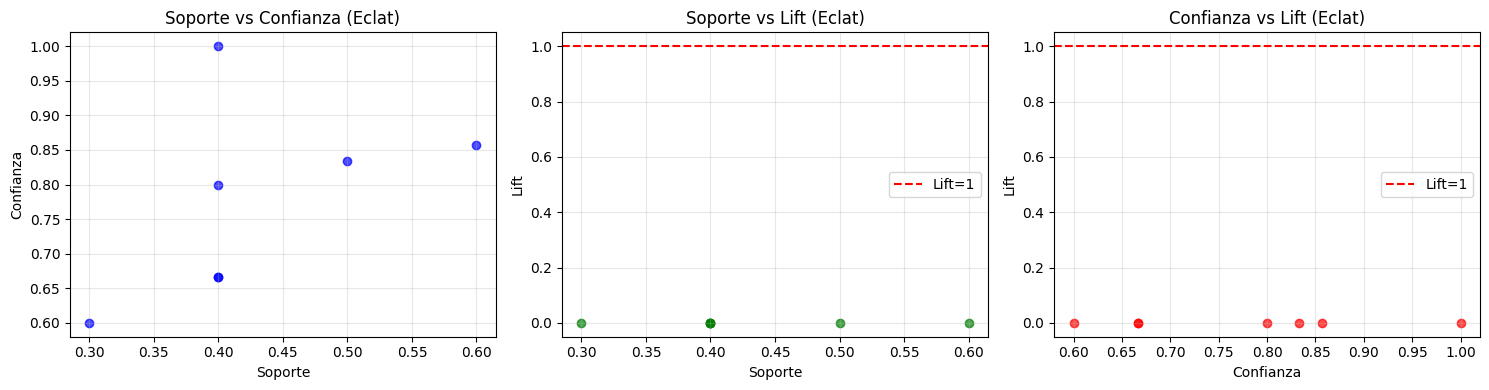

In [8]:
import matplotlib.pyplot as plt

if rules:
    # Convertir reglas a DataFrame para visualización
    df_rules = pd.DataFrame(rules)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Gráfico de soporte vs confianza
    axes[0].scatter(df_rules['support'], df_rules['confidence'], alpha=0.7, c='blue')
    axes[0].set_xlabel('Soporte')
    axes[0].set_ylabel('Confianza')
    axes[0].set_title('Soporte vs Confianza (Eclat)')
    axes[0].grid(True, alpha=0.3)

    # Gráfico de soporte vs lift
    axes[1].scatter(df_rules['support'], df_rules['lift'], alpha=0.7, c='green')
    axes[1].set_xlabel('Soporte')
    axes[1].set_ylabel('Lift')
    axes[1].set_title('Soporte vs Lift (Eclat)')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=1, color='red', linestyle='--', label='Lift=1')
    axes[1].legend()

    # Gráfico de confianza vs lift
    axes[2].scatter(df_rules['confidence'], df_rules['lift'], alpha=0.7, c='red')
    axes[2].set_xlabel('Confianza')
    axes[2].set_ylabel('Lift')
    axes[2].set_title('Confianza vs Lift (Eclat)')
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=1, color='red', linestyle='--', label='Lift=1')
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No hay reglas para visualizar.")

In [1]:
# ============================================================
# 📦 CARGANDO DATASET ONLINE RETAIL II (ARCHIVO EXCEL)
# ============================================================

print("="*60)
print("📦 CARGANDO DATASET ONLINE RETAIL II")
print("="*60)

import pandas as pd
import time
from google.colab import files

# Instalar pyECLAT (solo la primera vez)
!pip install pyECLAT -q

from pyECLAT import ECLAT

try:
    # --------------------------------------------------------
    # Paso 1: Subir el archivo Excel
    # --------------------------------------------------------
    print("📤 Selecciona el archivo 'online_retail_II.xlsx'")
    uploaded = files.upload()

    # Obtener el nombre del archivo subido
    filename = list(uploaded.keys())[0]

    # --------------------------------------------------------
    # Paso 2: Leer la hoja Year 2010-2011
    # --------------------------------------------------------
    print("\n📥 Leyendo archivo...")

    df = pd.read_excel(
        filename,
        sheet_name="Year 2010-2011"
    )

    print(f"✅ Dataset cargado correctamente.")
    print(f"📊 Dimensiones: {df.shape}")

    print("\n📋 Primeras 5 filas:")
    print(df.head())

    # --------------------------------------------------------
    # Paso 3: Filtrar Reino Unido
    # --------------------------------------------------------
    df_uk = df[df["Country"] == "United Kingdom"].copy()

    # Eliminar registros incompletos
    df_uk.dropna(subset=["Invoice", "Description"], inplace=True)

    print(f"\n📊 Transacciones Reino Unido: {len(df_uk)}")

    # --------------------------------------------------------
    # Paso 4: Crear lista de transacciones (formato para pyECLAT)
    # --------------------------------------------------------
    # pyECLAT espera un DataFrame con columnas: 'transaction_id', 'item'
    # o una lista de listas.
    # Vamos a preparar los datos como lista de listas, pero
    # también podemos crear un DataFrame con transacciones y items.

    transactions_large = (
        df_uk.groupby("Invoice")["Description"]
             .apply(lambda x: list(set(x)))   # elimina productos repetidos
             .tolist()
    )

    print(f"📄 Número de facturas: {len(transactions_large)}")

    if len(transactions_large) > 0:
        print("\nEjemplo de transacción:")
        print(transactions_large[0][:5])

    # --------------------------------------------------------
    # Paso 5: Ejecutar Eclat con pyECLAT
    # --------------------------------------------------------
    print("\n⏳ Ejecutando Eclat con pyECLAT...")

    start_time = time.time()

    # Crear instancia de ECLAT
    eclat = ECLAT(data=transactions_large, verbose=True)

    # Ejecutar mining con soporte mínimo (porcentaje)
    # min_support = 0.01 significa 1% de las transacciones
    # Para que sea más rápido, podemos probar con 0.02 o 0.03
    # Pero también podemos usar el soporte absoluto (min_support=50, por ejemplo)
    # Vamos a usar 0.01 para mantener consistencia

    # Si queremos usar solo las primeras 1000, podemos hacer:
    # eclat = ECLAT(data=transactions_large[:1000], verbose=True)
    # Pero pyECLAT es rápido, podemos usar todas las transacciones (unas 500k)
    # Aunque puede ser pesado, mejor usamos una muestra representativa.
    # Tomamos 5000 transacciones para equilibrar velocidad y representatividad
    sample_size = min(5000, len(transactions_large))
    transactions_sample = transactions_large[:sample_size]

    print(f"🔹 Usando {sample_size} transacciones para el mining.")

    # Re-inicializar con la muestra
    eclat = ECLAT(data=transactions_sample, verbose=True)

    # Ejecutar mining
    min_support_abs = int(0.01 * len(transactions_sample))  # soporte absoluto
    print(f"🔹 Soporte mínimo absoluto: {min_support_abs} transacciones")

    # Obtener itemsets frecuentes
    # get_Itemsets(min_support=0.01) usa soporte relativo
    frequent_itemsets, support_dict = eclat.fit(min_support=0.01)

    end_time = time.time()

    print(f"\n✅ Tiempo: {end_time-start_time:.2f} segundos")
    print(f"📊 Itemsets encontrados: {len(frequent_itemsets)}")

    if frequent_itemsets:
        print("\nTop 5 Itemsets (por soporte):")
        # Ordenar por soporte descendente
        sorted_itemsets = sorted(frequent_itemsets.items(), key=lambda x: x[1]['support'], reverse=True)
        for i, (itemset, info) in enumerate(sorted_itemsets[:5]):
            support = info['support'] / len(transactions_sample)  # soporte relativo
            print(f"{itemset} --> soporte = {support:.3f} ({support*100:.2f}%)")

except Exception as e:
    print(f"\n❌ Error: {e}")

📦 CARGANDO DATASET ONLINE RETAIL II
📤 Selecciona el archivo 'online_retail_II.xlsx'


Saving online_retail_II.xlsx to online_retail_II (1).xlsx

📥 Leyendo archivo...
✅ Dataset cargado correctamente.
📊 Dimensiones: (541910, 8)

📋 Primeras 5 filas:
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  

📊 Transacciones Reino Unido: 494024
📄 Número de facturas:

## 🔍 Interpretación de los resultados

### ¿Qué hace Eclat de manera diferente?

1. **Formato vertical (TID-lists)**:
   - En lugar de recorrer transacción por transacción, Eclat almacena para cada ítem la lista de IDs de transacciones donde aparece.
   - El soporte de un itemset se calcula intersectando las TID-lists de sus componentes.

2. **Búsqueda en profundidad**:
   - Eclat explora el espacio de búsqueda de manera recursiva, profundizando en combinaciones de ítems antes de pasar a otras ramas.
   - Esto permite un uso más eficiente de la memoria en muchos casos.

3. **Ventajas sobre Apriori**:
   - Generalmente más rápido (hasta un orden de magnitud)[reference:16]
   - No requiere generar candidatos y verificar subconjuntos
   - Más eficiente para datasets con muchos ítems frecuentes

4. **Desventajas**:
   - Puede consumir mucha memoria al almacenar TID-lists[reference:17]
   - En datasets muy densos, las intersecciones pueden ser costosas[reference:18]

### Reglas encontradas en este ejemplo:

- Las reglas con mayor soporte indican combinaciones de productos que se compran juntos con frecuencia.
- Las reglas con alto lift indican asociaciones fuertes y no triviales.
- Estas reglas pueden utilizarse para:
  - Recomendación de productos (cross-selling)
  - Optimización de disposición en tiendas
  - Promociones y ofertas combinadas